In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
import sqlite3
import pandas as pd

# --- A1.1 Connexion à la base fusionnée ---
db_path = "/content/drive/MyDrive/Projets/FDD/bd/fusion_ieee.db"
conn = sqlite3.connect(db_path)

In [74]:
!pip install pyvis

In [75]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pyvis.network import Network

In [76]:
articles = pd.read_sql("SELECT * FROM articles", conn)
authors = pd.read_sql("SELECT * FROM authors", conn)
article_authors = pd.read_sql("SELECT * FROM article_authors", conn)
keywords = pd.read_sql("SELECT * FROM keywords", conn)
author_labs = pd.read_sql("SELECT * FROM author_labs", conn)
labs = pd.read_sql("SELECT * FROM labs", conn)

In [77]:
print("Nombre d'articles :", len(articles))
print("Nombre d'auteurs :", len(authors))
print("Nombre de laboratoires :", len(labs))
print("Nombre de mots-clés :", len(keywords))
print("\nValeurs manquantes par table :")
for df, name in zip([articles, authors, labs, keywords], ['articles', 'authors', 'labs', 'keywords']):
    print(f"{name}:\n", df.isnull().sum(), "\n")

Nombre d'articles : 10077
Nombre d'auteurs : 53493
Nombre de laboratoires : 14522
Nombre de mots-clés : 159043

Valeurs manquantes par table :
articles:
 id                   0
title                0
link                 0
abstract             5
doi                  0
date_publication    14
publisher            0
published_in         0
electronic_issn     53
source               0
dtype: int64 

authors:
 id        0
name      0
source    0
dtype: int64 

labs:
 id           0
lab_name     0
source_db    0
country      0
dtype: int64 

keywords:
 id            0
article_id    0
type          0
keyword       0
source        0
dtype: int64 



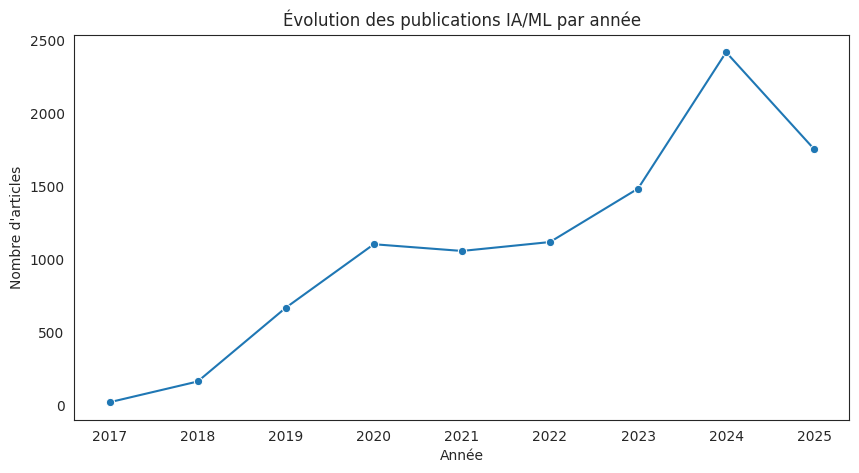

In [78]:
articles['year'] = pd.to_datetime(articles['date_publication'], errors='coerce').dt.year
year_counts = articles.groupby('year').size().reset_index(name='count')

plt.figure(figsize=(10,5))
sns.lineplot(data=year_counts, x='year', y='count', marker='o')
plt.title("Évolution des publications IA/ML par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'articles")
plt.xticks(year_counts['year'].dropna().astype(int))
plt.show()

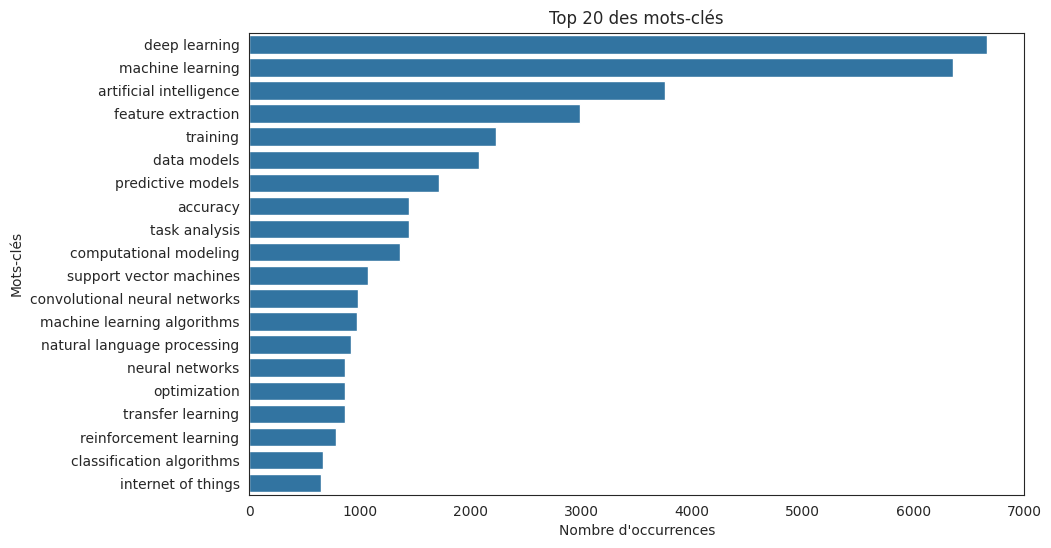

In [79]:
top_keywords = keywords['keyword'].value_counts().head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=top_keywords.values, y=top_keywords.index)
plt.title("Top 20 des mots-clés")
plt.xlabel("Nombre d'occurrences")
plt.ylabel("Mots-clés")
plt.show()

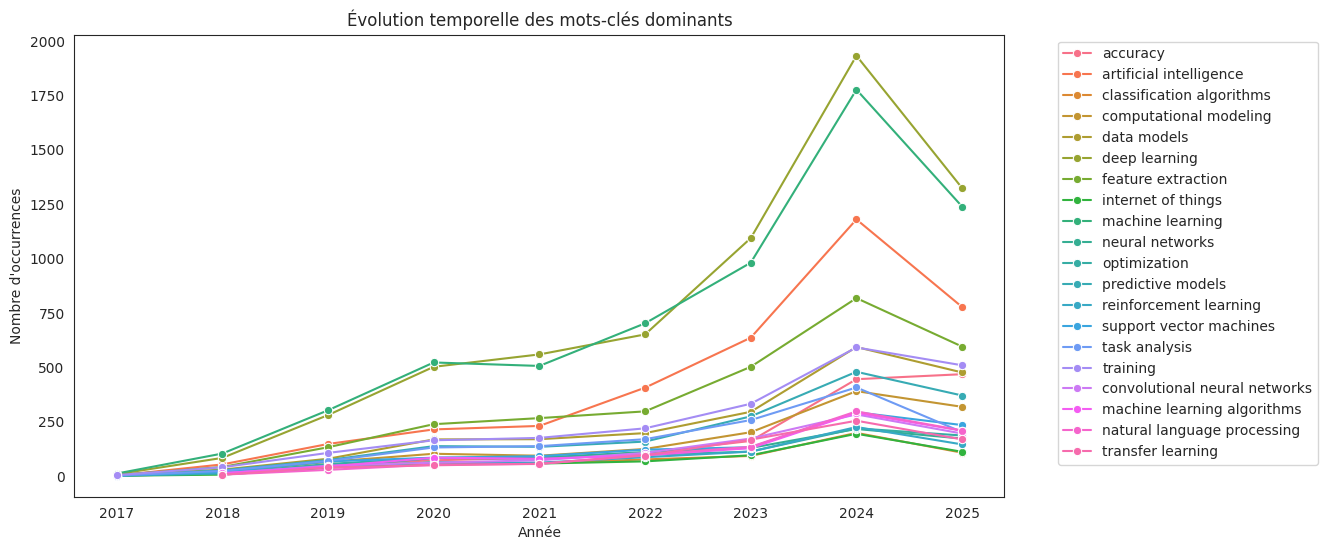

In [80]:
keywords_articles = keywords.merge(articles[['id','year']], left_on='article_id', right_on='id')
keywords_trend = keywords_articles.groupby(['year','keyword']).size().reset_index(name='count')
top_keywords_list = top_keywords.index.tolist()
keywords_trend_top = keywords_trend[keywords_trend['keyword'].isin(top_keywords_list)]

plt.figure(figsize=(12,6))
sns.lineplot(data=keywords_trend_top, x='year', y='count', hue='keyword', marker='o')
plt.title("Évolution temporelle des mots-clés dominants")
plt.xlabel("Année")
plt.ylabel("Nombre d'occurrences")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

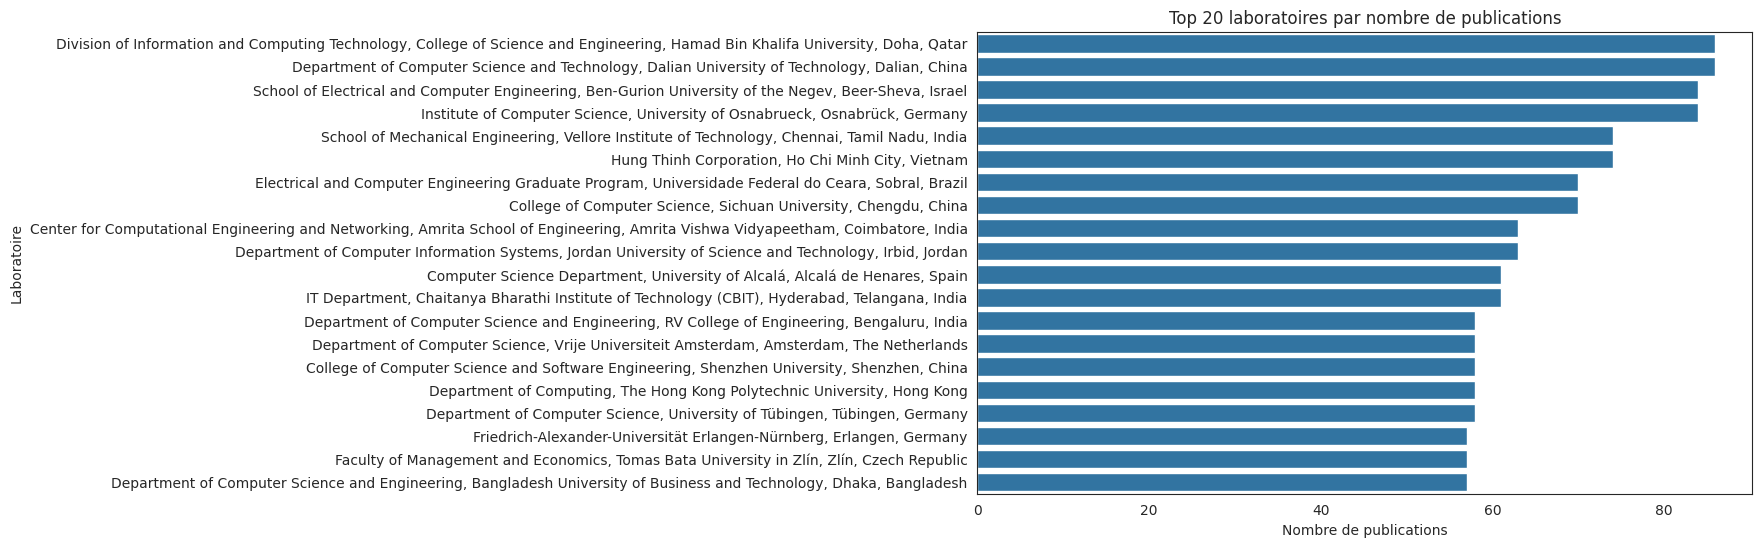

In [81]:
author_labs_full = author_labs.merge(labs, left_on='lab_id', right_on='id').merge(article_authors, left_on='author_id', right_on='author_id')
lab_counts = author_labs_full['lab_name'].value_counts().head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=lab_counts.values, y=lab_counts.index)
plt.title("Top 20 laboratoires par nombre de publications")
plt.xlabel("Nombre de publications")
plt.ylabel("Laboratoire")
plt.show()

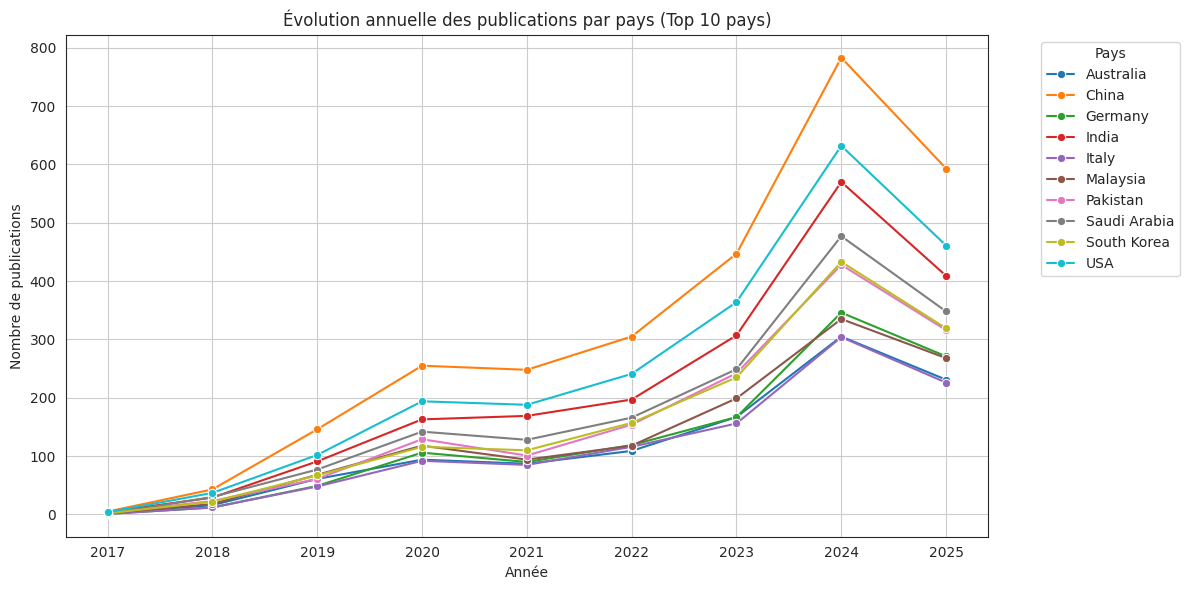

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

articles['year'] = pd.to_datetime(articles['date_publication'], errors='coerce').dt.year

# Jointure les tables
article_authors_labs = (
    article_authors
    .merge(author_labs, on='author_id', how='left')
    .merge(labs[['id','country']], left_on='lab_id', right_on='id', how='left')
    .merge(articles[['id','year']], left_on='article_id', right_on='id', how='left')
)

article_authors_labs = article_authors_labs.dropna(subset=['lab_id','country'])

valeurs_a_exclure = ['Unknown', 'unknown', 'Inconnu']
article_authors_labs = article_authors_labs[~article_authors_labs['country'].isin(valeurs_a_exclure)]

pubs_per_country_year = (
    article_authors_labs
    .groupby(['country','year'])
    .agg({'article_id':'nunique'})
    .reset_index()
    .rename(columns={'article_id':'n_articles'})
)

# Filtre des Top 10 pays
top_countries = pubs_per_country_year.groupby('country')['n_articles'].sum().sort_values(ascending=False).head(10).index
pubs_top_countries = pubs_per_country_year[pubs_per_country_year['country'].isin(top_countries)]

# Tracer le graphique
plt.figure(figsize=(12,6))
sns.lineplot(
    data=pubs_top_countries,
    x='year', y='n_articles',
    hue='country', marker='o', palette='tab10'
)
plt.title("Évolution annuelle des publications par pays (Top 10 pays)")
plt.xlabel("Année")
plt.ylabel("Nombre de publications")

# Gestion des ticks de l'axe X
unique_years = pubs_top_countries['year'].dropna().sort_values().unique()
if len(unique_years) > 0:
    plt.xticks(unique_years.astype(int))

plt.legend(title="Pays", bbox_to_anchor=(1.05, 1), loc='upper left') # Légende à l'extérieur pour plus de clarté
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1314327030.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


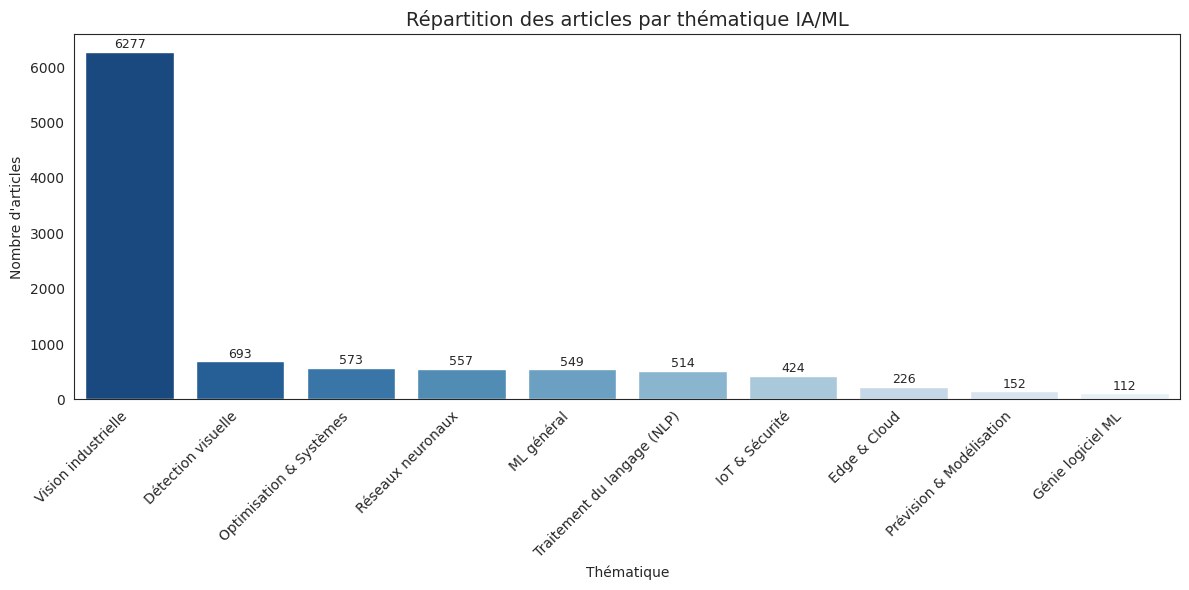


Mots-clés représentatifs par thématique :

Prévision & Modélisation : forecasting, learning, models, machine, deep, load, artificial, predictive, neural, data
Vision industrielle : intelligence, artificial, optical, image, digital, imaging, industrial, systems, metaverse, design
Détection visuelle : learning, deep, machine, feature, artificial, intelligence, extraction, image, imaging, detection
ML général : learning, models, data, machine, deep, modeling, predictive, artificial, intelligence, analysis
Réseaux neuronaux : learning, neural, networks, deep, machine, convolutional, feature, artificial, models, network
Edge & Cloud : learning, computing, edge, machine, deep, cloud, quantum, data, artificial, intelligence
IoT & Sécurité : learning, communication, machine, deep, internet, things, intelligence, artificial, wireless, security
Génie logiciel ML : software, learning, machine, deep, models, algorithms, engineering, artificial, intelligence, data
Traitement du langage (NLP) : lea

In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 1. Création d'une colonne "keywords_str" par article
keywords_str = keywords.groupby('article_id')['keyword'].apply(lambda x: ' '.join(x)).reset_index()
articles_keywords = articles.merge(keywords_str, left_on='id', right_on='article_id', how='left')

# Remplir les NaN
articles_keywords['keyword_str'] = articles_keywords['keyword'].fillna('')

# 2. TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
X = tfidf.fit_transform(articles_keywords['keyword_str'])

# 3. KMeans
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
articles_keywords['cluster'] = kmeans.fit_predict(X)

# 4. Attribution de noms de thématiques
cluster_labels = {
    0: "Prévision & Modélisation",
    1: "Vision industrielle",
    2: "Détection visuelle",
    3: "ML général",
    4: "Réseaux neuronaux",
    5: "Edge & Cloud",
    6: "IoT & Sécurité",
    7: "Génie logiciel ML",
    8: "Traitement du langage (NLP)",
    9: "Optimisation & Systèmes"
}

articles_keywords["cluster_label"] = articles_keywords["cluster"].map(cluster_labels)

# 5. Graphique amélioré
cluster_counts = articles_keywords["cluster_label"].value_counts()

plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    palette="Blues_r"
)

# Ajout des valeurs au-dessus des barres
for i, v in enumerate(cluster_counts.values):
    ax.text(i, v + max(cluster_counts.values)*0.01, str(v), ha='center', fontsize=9)

plt.xticks(rotation=45, ha="right")
plt.title("Répartition des articles par thématique IA/ML", fontsize=14)
plt.ylabel("Nombre d'articles")
plt.xlabel("Thématique")
plt.tight_layout()
plt.show()

# 6. Top mots-clés par cluster
terms = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

print("\nMots-clés représentatifs par thématique :\n")
for i in range(n_clusters):
    print(f"{cluster_labels[i]} : ", end='')
    print(', '.join([terms[ind] for ind in order_centroids[i, :10]]))

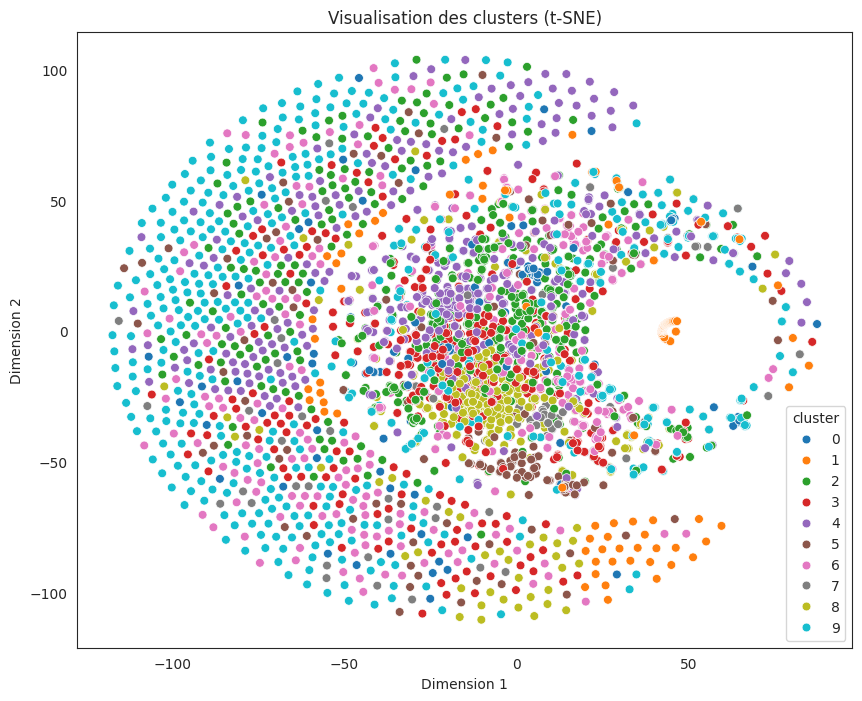

In [84]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Réduction de dimension avec t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_tsne = tsne.fit_transform(X.toarray())

# Ajout des coordonnées au dataframe
articles_keywords["tsne_x"] = X_tsne[:, 0]
articles_keywords["tsne_y"] = X_tsne[:, 1]

# Visualisation
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="tsne_x",
    y="tsne_y",
    hue="cluster",
    palette="tab10",
    data=articles_keywords,
    legend="full",
    s=40
)

plt.title("Visualisation des clusters (t-SNE)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()